# 📖 Panchatantra Stories — NLP Analysis

---

## 🧾 Project Overview

This project performs a **complete Natural Language Processing (NLP) analysis** on 50 ancient Indian fables from the **Panchatantra** — one of the oldest collections of moral stories in the world.

Each story in our dataset contains:
- 📝 A **story** paragraph (the narrative)
- 💡 A **moral** (the lesson)
- 😮 An **emotion** label (e.g., fear, joy, anger)
- 🎯 A **theme** label (e.g., trust, intelligence, betrayal)

---

## 🔍 What We Analyse

| # | Analysis | What it tells us |
|---|----------|------------------|
| 1 | Text Cleaning & Preprocessing | Prepare raw text for NLP |
| 2 | Tokenization & Lemmatization | Break text into base word forms |
| 3 | Word Cloud | Most frequent meaningful words |
| 4 | Emotion Distribution | Which emotions dominate the stories |
| 5 | Moral Theme Analysis | Which themes appear most |
| 6 | Character Dominance | Which animals appear most frequently |
| 7 | Top Action Words & Bigrams | What actions drive the stories |
| 8 | Story Length Analysis | How long are the stories |
| 9 | Story Intelligence Score | How 'clever' each story is |
| 10 | Sentiment Analysis | Positive vs negative tone per story |
| 11 | Interactive Dashboard | All 11 charts in one page |

---

## 📁 Dataset
- **File:** `panchatantra_full_50.csv`
- **Stories:** 50
- **Columns:** `story_id`, `title`, `story`, `moral`, `emotion`, `theme`

---

> **Author:** Your Name  
> **Tools:** Python, NLTK, Plotly, NetworkX, Scikit-learn, WordCloud

---
# ⚙️ STEP 1 — Install & Import All Libraries

We install and import everything we need **at the very beginning** so nothing breaks later.

- `pandas` → work with the CSV dataset (tables)
- `nltk` → NLP tools: tokenization, stopwords, lemmatization, sentiment
- `matplotlib / seaborn` → draw charts
- `wordcloud` → generate the word cloud image
- `plotly` → interactive charts for the dashboard
- `networkx` → build the word co-occurrence network graph
- `scikit-learn` → TF-IDF vectorizer and cosine similarity

In [ ]:
# Install all required libraries
# The ! means 'run this as a terminal command' in Google Colab
!pip install pandas numpy matplotlib seaborn nltk wordcloud plotly scikit-learn networkx -q

In [ ]:
# ── Standard Python libraries (no install needed) ──────────────────────────────
import re                          # For cleaning text using patterns
import io                          # For reading uploaded file bytes
import base64                      # For converting images to embed in HTML
import itertools                   # For generating word pairs (combinations)
from io import BytesIO             # For saving matplotlib figures to memory
from collections import Counter, defaultdict  # For counting words and edges

# ── Data handling ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# ── Word Cloud ──────────────────────────────────────────────────────────────────
from wordcloud import WordCloud

# ── NLP — NLTK ─────────────────────────────────────────────────────────────────
import nltk
nltk.download('stopwords',    quiet=True)  # Common words to remove (the, is, a)
nltk.download('punkt',        quiet=True)  # Sentence/word splitter
nltk.download('punkt_tab',    quiet=True)  # Updated punkt data
nltk.download('wordnet',      quiet=True)  # Word base forms (running → run)
nltk.download('vader_lexicon',quiet=True)  # Sentiment scoring dictionary

from nltk.corpus              import stopwords
from nltk.tokenize            import word_tokenize, sent_tokenize
from nltk.stem                import WordNetLemmatizer
from nltk                     import bigrams
from nltk.sentiment           import SentimentIntensityAnalyzer

# ── Machine Learning ────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise        import cosine_similarity

# ── Network Graph ───────────────────────────────────────────────────────────────
import networkx as nx

# ── Interactive Charts ──────────────────────────────────────────────────────────
import plotly.graph_objects as go
import plotly.express       as px
import plotly.io            as pio
from plotly.subplots import make_subplots

# ── Google Colab file upload tool ───────────────────────────────────────────────
from google.colab import files

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
# 📂 STEP 2 — Upload & Load the Dataset

Upload the file `panchatantra_full_50.csv` when the button appears.

After uploading, we load it into a **DataFrame** (think of it as an Excel table in Python).

In [ ]:

import pandas as pd
df = pd.read_csv("panchatantra_full_50.csv")

# Show basic info about the dataset
print(f'✅ Dataset loaded successfully!')
print(f'   Rows (stories) : {len(df)}')
print(f'   Columns        : {list(df.columns)}')
print()
df.head(3)  # Show first 3 rows

✅ Dataset loaded successfully!
   Rows (stories) : 50
   Columns        : ['story_id', 'title', 'story', 'moral', 'emotion', 'theme']



,story_id,title,story,moral,emotion,theme
0,1,Monkey and Crocodile,"Deep within the heart of an ancient forest, th...",Never trust blindly; true friendship isn't bui...,betrayal,trust
1,2,Lion and Rabbit,In a lush jungle that had once rung with laugh...,Intelligence and presence of mind can overcome...,fear,intelligence
2,3,Fox and Crow,High up in the gnarled branches of an old oak ...,Beware of flattery; it is often the weapon of ...,deception,greed


In [ ]:
# Quick look at one full story so we know what the raw text looks like
print('📖 Sample Story (RAW):')
print('-' * 60)
print(df['story'][0])

📖 Sample Story (RAW):
------------------------------------------------------------
Deep within the heart of an ancient forest, there lived a clever monkey who'd made his home atop a sprawling mango tree beside a wide, glittering river. The tree's branches, heavy with ripe fruit, hung low over the water's edge — and it was here that the monkey first befriended a large crocodile who swam nearby each morning. "You're most welcome to share my fruits," the monkey offered generously, tossing mangoes into the water with a grin. Days turned to weeks, and the two became inseparable companions. However, the crocodile's wife, suspicious of her husband's long absences, demanded an explanation. Upon hearing of the sweet fruits, she grew cunning and greedy. "If those mangoes are so delicious," she whispered, "imagine how sweet the heart of a monkey who eats them daily must be!" The crocodile, torn between love and loyalty, reluctantly agreed to bring his friend's heart to her. He invited the monkey 

---
# 🧹 STEP 3 — Text Cleaning & Preprocessing

Raw text contains a lot of **noise** — punctuation, capital letters, apostrophes, numbers — that computers can't understand for NLP.

We also remove **stopwords** — extremely common words like *the, is, a, and* — that carry no meaningful information.

We use **two stopword lists**:
1. Standard English stopwords from NLTK
2. Extra domain-specific words common in folk tales (e.g., *said, came, went*) that add no analytical value

In [ ]:
# ── Build combined stopword list ────────────────────────────────────────────────

# Standard English stopwords (the, is, a, and, etc.)
base_stopwords = set(stopwords.words('english'))

# Extra words that are common in folk tales but not analytically useful
extra_stopwords = {
    'said', 'came', 'went', 'got', 'told', 'asked', 'made', 'let',
    'also', 'back', 'away', 'upon', 'one', 'two', 'day', 'time',
    'man', 'way', 'could', 'would', 'become', 'became', 'later',
    'soon', 'then', 'there', 'worked', 'helped', 'learned', 'saved',
    'ensured', 'restored', 'removed', 'returned', 'happened',
    'followed', 'planned', 'found', 'shown', 'needed', 'matters',
    'wins', 'failed', 'escaped', 'without', 'every', 'still', 'even',
    'much', 'well', 'first', 'long', 'finally', 'simply', 'entirely',
    'rather', 'already', 'however', 'though', 'before', 'after',
    'within', 'toward', 'between', 'around', 'against', 'along'
}

# Combine both lists into one
all_stopwords = base_stopwords | extra_stopwords

print(f'✅ Total stopwords: {len(all_stopwords)}')

✅ Total stopwords: 259


In [ ]:
# ── Define cleaning functions ───────────────────────────────────────────────────

def clean_to_tokens(text):
    """
    Cleans a story and returns a LIST of meaningful words.
    Steps:
      1. Lowercase everything
      2. Remove punctuation, numbers, special characters
      3. Split into individual words
      4. Remove stopwords and very short words (length <= 2)
    """
    text = str(text).lower()                        # Step 1: lowercase
    text = re.sub(r'[^a-z\s]', '', text)            # Step 2: remove non-letters
    words = text.split()                            # Step 3: split into words
    words = [w for w in words                       # Step 4: filter stopwords
             if w not in all_stopwords
             and len(w) > 2]
    return words

def clean_to_string(text):
    """
    Same as clean_to_tokens but returns a STRING.
    Needed for tools like TF-IDF that expect string input.
    """
    return ' '.join(clean_to_tokens(text))

def clean_basic(text):
    """
    Basic cleaning: lowercase + remove punctuation only.
    Used for tokenization steps where we need full sentences.
    """
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# ── Apply cleaning to the dataset ──────────────────────────────────────────────

# Token list per story (used for NLP analysis)
df['tokens'] = df['story'].apply(clean_to_tokens)

# Cleaned string per story (used for TF-IDF, wordcloud)
df['clean_story'] = df['story'].apply(clean_to_string)

# Word count of original story
df['word_count'] = df['story'].apply(lambda x: len(str(x).split()))

print('✅ Text cleaning complete!')
print()
print('Before cleaning:', df['story'][0][:80], '...')
print()
print('After  cleaning:', df['clean_story'][0][:80], '...')

✅ Text cleaning complete!

Before cleaning: Deep within the heart of an ancient forest, there lived a clever monkey who'd ma ...

After  cleaning: deep heart ancient forest lived clever monkey whod home atop sprawling mango tre ...


---
# 🔤 STEP 4 — Tokenization & Lemmatization

### What is Tokenization?
**Tokenization** = splitting text into individual units (words or sentences).
- *Word tokens:* `['lion', 'chased', 'rabbit', ...]`
- *Sentence tokens:* `['Lion chased the rabbit.', 'Rabbit escaped.']`

### What is Lemmatization?
**Lemmatization** = reducing a word to its root/base form using a dictionary.
- `running → run`
- `tricked → trick`
- `animals → animal`

This ensures `tricked` and `trick` are counted as the **same word**, improving accuracy.

In [ ]:
# ── Word Tokenization ───────────────────────────────────────────────────────────
# Split each cleaned story into individual word tokens
df['word_tokens'] = df['clean_story'].apply(word_tokenize)

# ── Sentence Tokenization ───────────────────────────────────────────────────────
# Split each ORIGINAL story into sentences (we use original to keep punctuation)
df['sent_tokens'] = df['story'].apply(sent_tokenize)

# Show the result
print('✅ Tokenization complete!')
print()
print('Word tokens (first story, first 8 words):')
print(df['word_tokens'][0][:8])
print()
print('Sentence tokens (first story, first 2 sentences):')
print(df['sent_tokens'][0][:2])

✅ Tokenization complete!

Word tokens (first story, first 8 words):
['deep', 'heart', 'ancient', 'forest', 'lived', 'clever', 'monkey', 'whod']

Sentence tokens (first story, first 2 sentences):
["Deep within the heart of an ancient forest, there lived a clever monkey who'd made his home atop a sprawling mango tree beside a wide, glittering river.", "The tree's branches, heavy with ripe fruit, hung low over the water's edge — and it was here that the monkey first befriended a large crocodile who swam nearby each morning."]


In [ ]:
# ── Lemmatization ───────────────────────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(token_list):
    """
    Takes a list of word tokens and returns their lemmatized (root) forms.
    Example: ['tricked', 'animals', 'running'] → ['trick', 'animal', 'run']
    """
    return [lemmatizer.lemmatize(word) for word in token_list]

df['lemmatized_tokens'] = df['word_tokens'].apply(lemmatize_tokens)

# Create a final clean text string from lemmatized tokens (used in some analyses)
df['final_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

print('✅ Lemmatization complete!')
print()
# Compare before and after lemmatization
sample_before = df['word_tokens'][0][:6]
sample_after  = df['lemmatized_tokens'][0][:6]
print('Before lemmatization:', sample_before)
print('After  lemmatization:', sample_after)

✅ Lemmatization complete!

Before lemmatization: ['deep', 'heart', 'ancient', 'forest', 'lived', 'clever']
After  lemmatization: ['deep', 'heart', 'ancient', 'forest', 'lived', 'clever']


In [ ]:
# ── Bigram Extraction ───────────────────────────────────────────────────────────
# A bigram is a pair of consecutive words — e.g., ('lion', 'chased')
# Bigrams help us find common word pairings / action sequences in stories

df['bigrams'] = df['lemmatized_tokens'].apply(lambda x: list(bigrams(x)))

print('✅ Bigrams extracted!')
print()
print('Sample bigrams from story 1:')
print(df['bigrams'][0][:5])

✅ Bigrams extracted!

Sample bigrams from story 1:
[('deep', 'heart'), ('heart', 'ancient'), ('ancient', 'forest'), ('forest', 'lived'), ('lived', 'clever')]


In [ ]:
# ── Show the full preprocessed DataFrame ───────────────────────────────────────
# This lets us confirm all new columns were created correctly
print('✅ All preprocessing columns added:')
print(list(df.columns))
print()
df[['title', 'clean_story', 'word_tokens', 'lemmatized_tokens', 'bigrams', 'word_count']].head(3)

✅ All preprocessing columns added:
['story_id', 'title', 'story', 'moral', 'emotion', 'theme', 'tokens', 'clean_story', 'word_count', 'word_tokens', 'sent_tokens', 'lemmatized_tokens', 'final_text', 'bigrams']



,title,clean_story,word_tokens,lemmatized_tokens,bigrams,word_count
0,Monkey and Crocodile,deep heart ancient forest lived clever monkey ...,"[deep, heart, ancient, forest, lived, clever, ...","[deep, heart, ancient, forest, lived, clever, ...","[(deep, heart), (heart, ancient), (ancient, fo...",237
1,Lion and Rabbit,lush jungle rung laughter birdsong fearsome li...,"[lush, jungle, rung, laughter, birdsong, fears...","[lush, jungle, rung, laughter, birdsong, fears...","[(lush, jungle), (jungle, rung), (rung, laught...",198
2,Fox and Crow,high gnarled branches old oak tree glossy blac...,"[high, gnarled, branches, old, oak, tree, glos...","[high, gnarled, branch, old, oak, tree, glossy...","[(high, gnarled), (gnarled, branch), (branch, ...",203


---
# 🔢 STEP 5 — Feature Engineering (NLP Scores)

We create three new numeric features from the text:

| Feature | What it measures |
|---------|------------------|
| `sentiment` | How positive or negative the story's tone is (-1 to +1) |
| `intel_score` | How 'clever' the story is — based on wisdom-related words |
| `main_character` | Which animal appears most in the story |

We also define the **animal list** and **action word list** used across multiple analyses.

In [ ]:
# ── Define domain-specific word lists ──────────────────────────────────────────

# Animals that appear as characters in Panchatantra stories
ANIMALS = [
    'monkey', 'lion', 'rabbit', 'fox', 'crow', 'tortoise', 'jackal',
    'elephant', 'snake', 'mouse', 'crocodile', 'deer', 'goat', 'tiger',
    'fish', 'dog', 'heron', 'crab', 'camel', 'bird', 'parrot', 'peacock',
    'donkey', 'crane', 'mongoose', 'hyena', 'wolf', 'hare', 'frog', 'hawk'
]

# Action words — verbs that represent key story events
ACTION_WORDS = [
    'tricked', 'escaped', 'saved', 'betrayed', 'warned', 'fought',
    'helped', 'planned', 'fled', 'attacked', 'sacrificed', 'cooperated',
    'defeated', 'punished', 'trusted', 'deceived', 'protected', 'united',
    'revealed', 'won'
]

print('✅ Animal list  :', len(ANIMALS), 'animals')
print('✅ Action words :', len(ACTION_WORDS), 'actions')

✅ Animal list  : 30 animals
✅ Action words : 20 actions


In [ ]:
# ── Sentiment Analysis using VADER ─────────────────────────────────────────────
# VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based
# sentiment analyser specifically designed for social/literary text.
# It returns a 'compound' score between -1 (very negative) and +1 (very positive)

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """Returns compound sentiment score for a piece of text."""
    return sia.polarity_scores(str(text))['compound']

df['sentiment'] = df['story'].apply(get_sentiment)

print('✅ Sentiment scores calculated!')
print()
print('Most positive story:', df.loc[df['sentiment'].idxmax(), 'title'],
      '→', df['sentiment'].max().round(3))
print('Most negative story:', df.loc[df['sentiment'].idxmin(), 'title'],
      '→', df['sentiment'].min().round(3))

✅ Sentiment scores calculated!



AttributeError: 'float' object has no attribute 'round'

In [ ]:
# ── Intelligence Score ─────────────────────────────────────────────────────────
# We score each story based on how many 'smart' words it contains.
# Smart words = vocabulary associated with wit, strategy, and cunning.
# Formula: (smart words found) / (total unique words) × 100

SMART_WORDS = {
    'intelligence', 'clever', 'wit', 'tricked', 'outsmarted', 'strategy',
    'cunning', 'wisdom', 'planned', 'deceived', 'outwitted', 'scheme',
    'calculated', 'resourceful', 'sharp'
}

def get_intelligence_score(text):
    """Scores a story's 'cleverness' based on smart vocabulary density."""
    token_set = set(clean_to_tokens(text))          # Unique cleaned words
    overlap   = len(token_set & SMART_WORDS)         # How many smart words found
    score     = overlap / max(len(token_set), 1) * 100
    return round(score, 2)

df['intel_score'] = df['story'].apply(get_intelligence_score)

print('✅ Intelligence scores calculated!')
print()
print('Top 5 most intelligent stories:')
print(df[['title', 'intel_score']].sort_values('intel_score', ascending=False).head())

✅ Intelligence scores calculated!

Top 5 most intelligent stories:
                        title  intel_score
25         Lion and the Hyena         2.35
2                Fox and Crow         1.94
0        Monkey and Crocodile         1.79
41  The Hare and the Tortoise         1.33
28     Fisherman and the Fish         1.30


In [ ]:
# ── Dominant Character Detection ────────────────────────────────────────────────
# For each story, find which animal is mentioned the most times.
# This tells us who the 'main character' of the story is.

def get_main_character(text):
    """Returns the most frequently mentioned animal in the story."""
    text   = str(text).lower()
    counts = {animal: text.count(animal) for animal in ANIMALS if animal in text}
    return max(counts, key=counts.get) if counts else 'other'

df['main_character'] = df['story'].apply(get_main_character)

# Action word count per story
def count_actions(text):
    """Returns a dict of how many times each action word appears."""
    text = str(text).lower()
    return {action: text.count(action) for action in ACTION_WORDS}

print('✅ Character and action features complete!')
print()
print('Character distribution:')
print(df['main_character'].value_counts().head(8))

✅ Character and action features complete!

Character distribution:
main_character
other       5
lion        4
monkey      4
elephant    4
jackal      4
crow        3
bird        3
deer        2
Name: count, dtype: int64


---
# 📊 STEP 6 — Exploratory Data Analysis (EDA) with Matplotlib & Seaborn

Now that the data is clean and features are built, we start **visualising** it.

These are the foundational charts that give us a clear picture of the dataset.

## ☁️ 6.1 — Word Cloud

A word cloud shows the **most frequent words** across all 50 stories.
- **Bigger word** = appears more often
- Stopwords are already removed, so only **meaningful words** appear

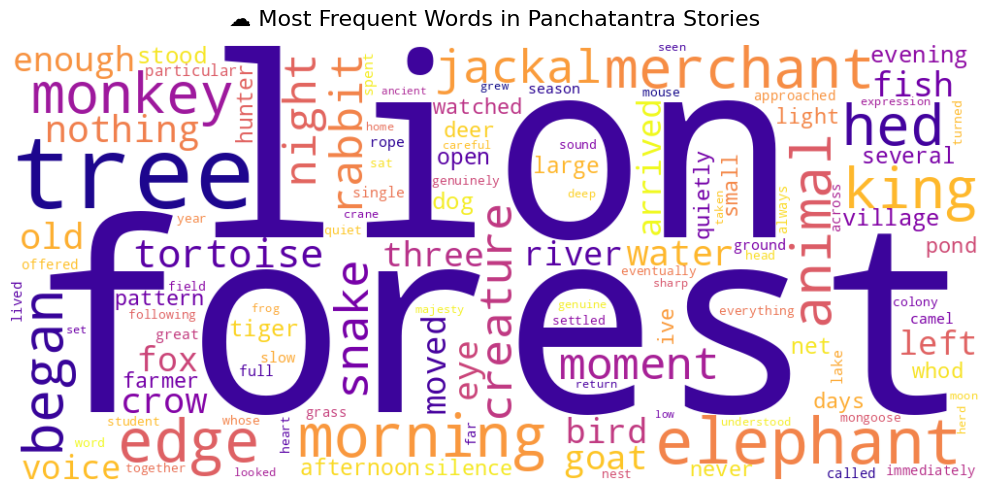

✅ Word cloud saved as wordcloud.png


In [ ]:
# Combine all cleaned stories into one large block of text
all_text = ' '.join(df['clean_story'])

# Generate the word cloud
wc = WordCloud(
    width            = 1000,
    height           = 450,
    background_color = 'white',
    colormap         = 'plasma',       # Colour scheme
    max_words        = 120,            # Maximum words to show
    collocations     = False,          # Don't count word pairs, just individual words
    random_state     = 42              # Fixed seed for reproducibility
).generate(all_text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('☁️ Most Frequent Words in Panchatantra Stories', fontsize=16, pad=14)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Word cloud saved as wordcloud.png')

## 😮 6.2 — Emotion Distribution

Which **emotions** appear most in Panchatantra stories?

Each story has one emotion label: *fear, anger, joy, betrayal, surprise*, etc.

/tmp/ipykernel_7735/3226164033.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


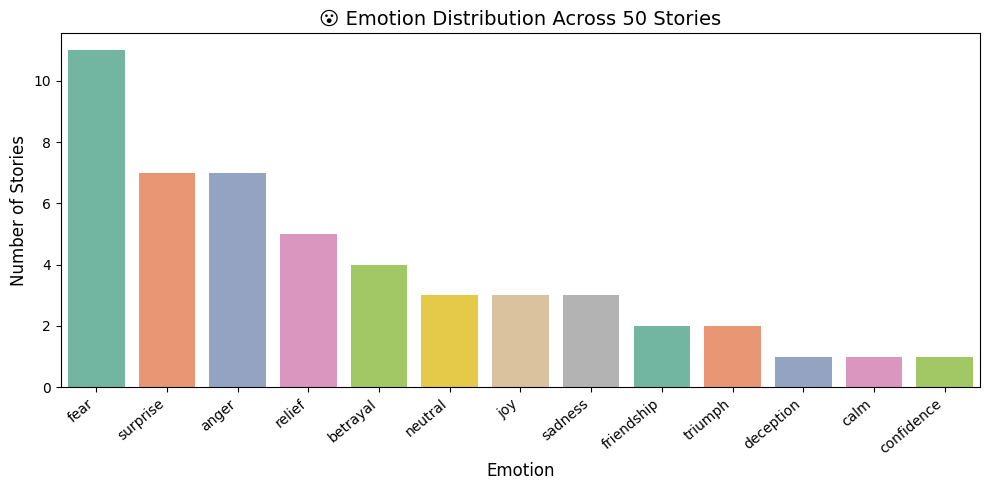

In [ ]:
plt.figure(figsize=(10, 5))

# Count how many stories have each emotion
emotion_order = df['emotion'].value_counts().index

sns.countplot(
    x     = 'emotion',
    data  = df,
    order = emotion_order,
    palette = 'Set2'
)

plt.title('😮 Emotion Distribution Across 50 Stories', fontsize=14)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Stories', fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('emotion_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 6.3 — Most Common Moral Themes

Which **moral themes** appear most often?

Themes like *trust, intelligence, betrayal, cooperation* represent the core lessons of the stories.

/tmp/ipykernel_7735/1111179825.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_7735/1111179825.py:16: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7735/1111179825.py:17: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('theme_distribution.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


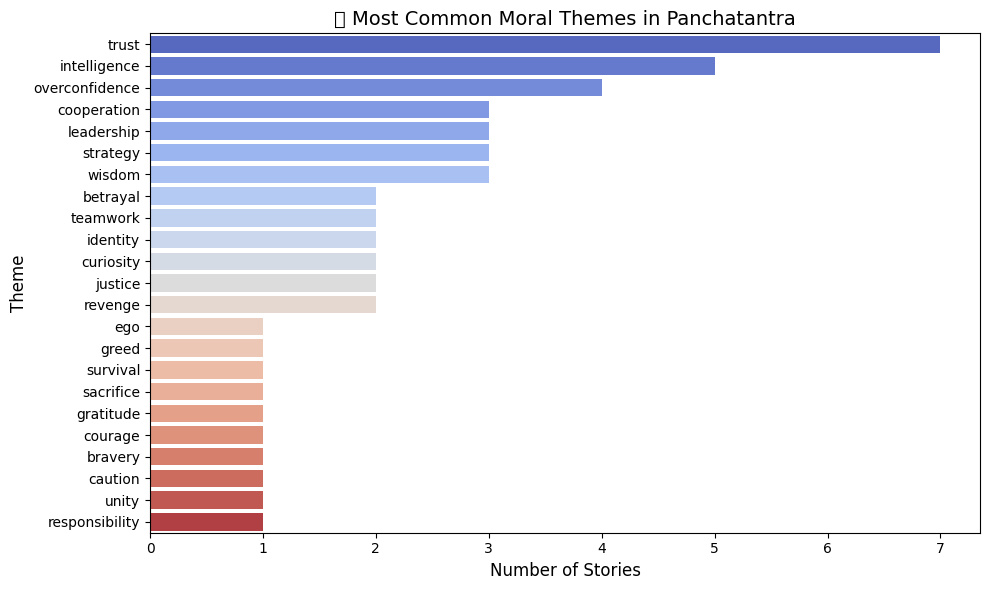

In [ ]:
plt.figure(figsize=(10, 6))

# Horizontal bar chart — easier to read theme labels
theme_order = df['theme'].value_counts().index

sns.countplot(
    y       = 'theme',
    data    = df,
    order   = theme_order,
    palette = 'coolwarm'
)

plt.title('🎯 Most Common Moral Themes in Panchatantra', fontsize=14)
plt.xlabel('Number of Stories', fontsize=12)
plt.ylabel('Theme', fontsize=12)
plt.tight_layout()
plt.savefig('theme_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 🦁 6.4 — Character Dominance

Which **animals** appear most frequently as main characters?

We check all 30 Panchatantra animals and count how many stories each appears in.

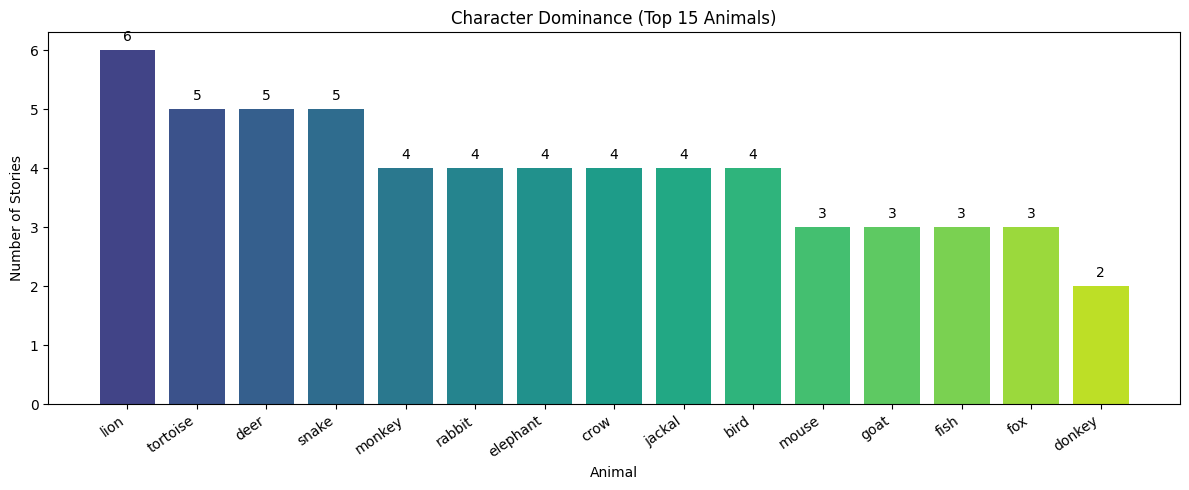

In [ ]:
# Count how many stories each animal appears in
character_counts = {}

for animal in ANIMALS:
    character_counts[animal] = df['story'].str.lower().str.contains(
        rf'\b{animal}\b', regex=True
    ).sum()

char_series = pd.Series(character_counts) \
                .sort_values(ascending=False) \
                .head(15)
plt.figure(figsize=(12, 5))

bars = plt.bar(
    char_series.index,
    char_series.values,
    color=plt.cm.viridis(np.linspace(0.2, 0.9, len(char_series)))
)

plt.title('Character Dominance (Top 15 Animals)')
plt.xlabel('Animal')
plt.ylabel('Number of Stories')
plt.xticks(rotation=35, ha='right')

for bar, val in zip(bars, char_series.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             str(val),
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

## ⚡ 6.5 — Top Action Words & Bigrams

### Action Words
We count how often key **action verbs** appear across all stories.
These reveal which actions drive Panchatantra narratives (e.g., *tricked, escaped, saved*).

### Bigrams
A **bigram** is two consecutive words together (e.g., *'lion chased'*, *'rabbit escaped'*).
Top bigrams reveal the most common **word pairings** in the stories.

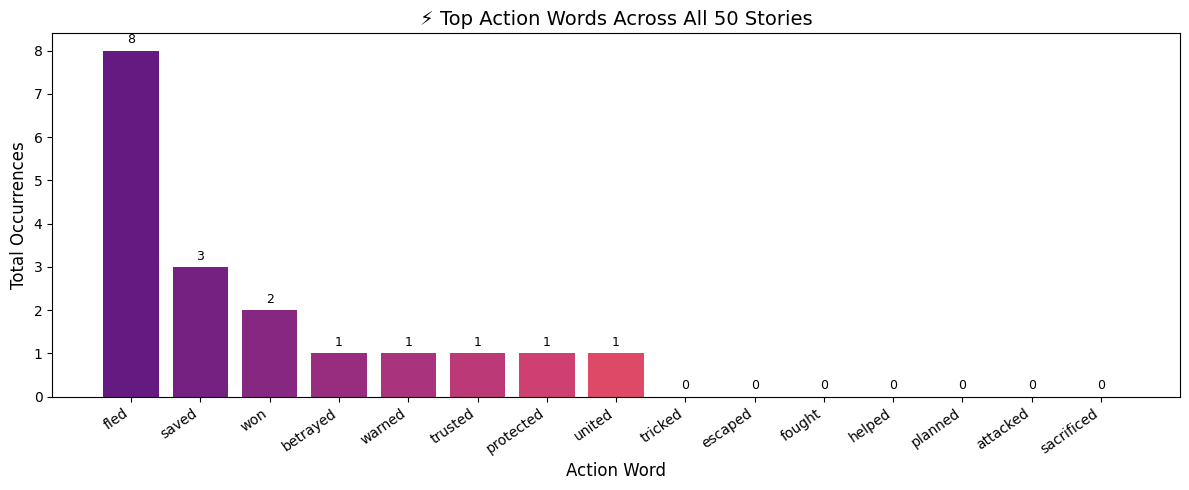

In [ ]:
# ── Top Action Words ────────────────────────────────────────────────────────────
action_totals = Counter()
for text in df['story']:
    action_totals.update(count_actions(text))

# Sort and get top 15 action words
top_actions = dict(sorted(action_totals.items(), key=lambda x: x[1], reverse=True)[:15])

plt.figure(figsize=(12, 5))
colors = plt.cm.magma(np.linspace(0.3, 0.9, len(top_actions)))
bars = plt.bar(top_actions.keys(), top_actions.values(), color=colors)
plt.title('⚡ Top Action Words Across All 50 Stories', fontsize=14)
plt.xlabel('Action Word', fontsize=12)
plt.ylabel('Total Occurrences', fontsize=12)
plt.xticks(rotation=35, ha='right')

for bar, val in zip(bars, top_actions.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('action_words.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_7735/2763302546.py:19: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7735/2763302546.py:20: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig('bigrams.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


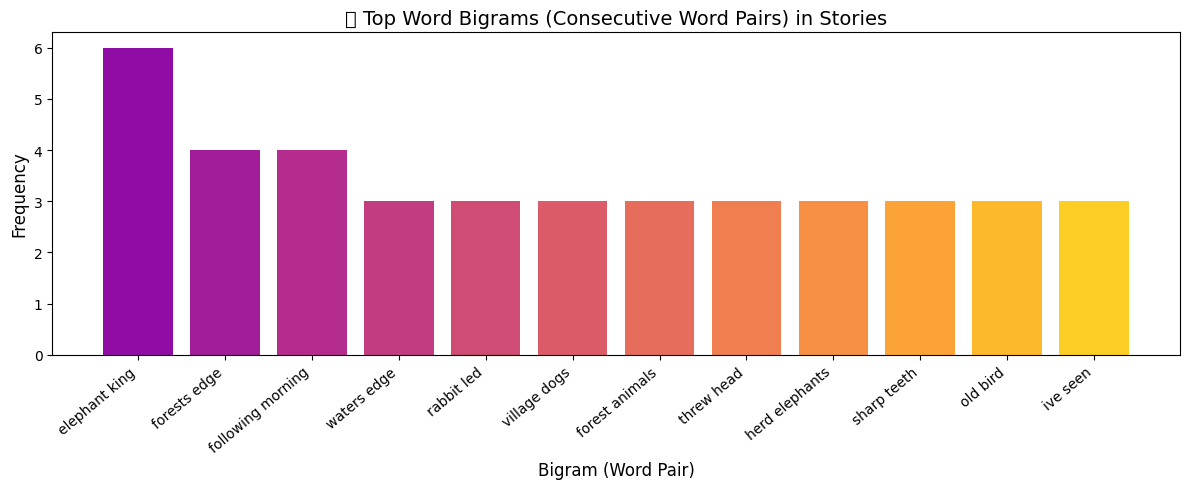

In [ ]:
# ── Top Bigrams ─────────────────────────────────────────────────────────────────
all_bigrams = []
for text in df['clean_story']:
    tokens = text.split()
    all_bigrams.extend(list(bigrams(tokens)))   # Extract all consecutive word pairs

# Get 12 most common bigrams
top_bigrams = Counter(all_bigrams).most_common(12)
bigram_labels = [' '.join(pair) for pair, _ in top_bigrams]
bigram_values = [count for _, count in top_bigrams]

plt.figure(figsize=(12, 5))
colors2 = plt.cm.plasma(np.linspace(0.3, 0.9, len(bigram_labels)))
plt.bar(bigram_labels, bigram_values, color=colors2)
plt.title('🔗 Top Word Bigrams (Consecutive Word Pairs) in Stories', fontsize=14)
plt.xlabel('Bigram (Word Pair)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('bigrams.png', dpi=150, bbox_inches='tight')
plt.show()

## 📏 6.6 — Story Length Analysis

How long are the stories? Are they mostly the same length, or do they vary a lot?

A **histogram** shows how word counts are distributed across all 50 stories.

/tmp/ipykernel_7735/1173882702.py:9: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7735/1173882702.py:10: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.savefig('story_length.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


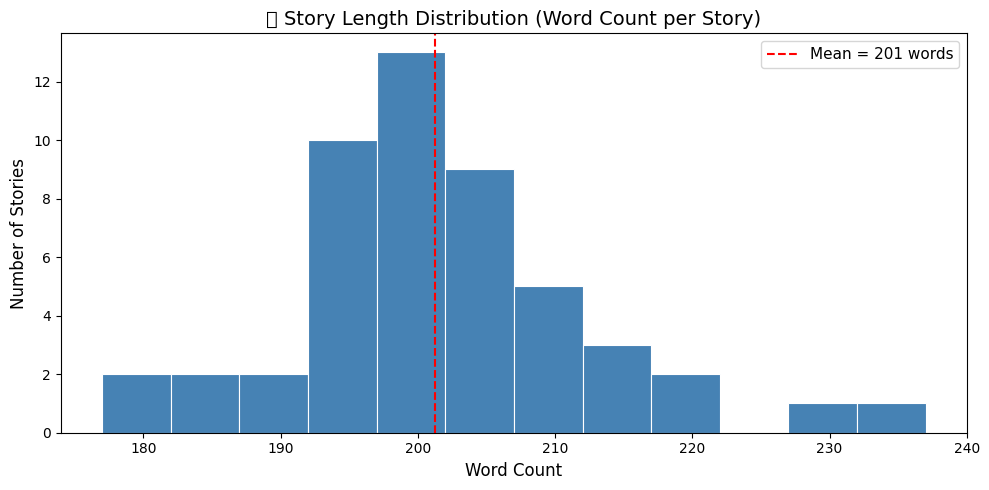

Average story length : 201.2 words
Shortest story       : 177 words
Longest story        : 237 words


In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df['word_count'], bins=12, color='steelblue', edgecolor='white', linewidth=0.8)
plt.axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f"Mean = {df['word_count'].mean():.0f} words")
plt.title('📏 Story Length Distribution (Word Count per Story)', fontsize=14)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Number of Stories', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('story_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Average story length : {df["word_count"].mean():.1f} words')
print(f'Shortest story       : {df["word_count"].min()} words')
print(f'Longest story        : {df["word_count"].max()} words')

## 🧠 6.7 — Story Intelligence Score

We rank stories by their **intelligence score** — a measure of how many 'clever' vocabulary words they contain relative to total word count.

Stories with more strategic, wisdom-based language score higher.

/tmp/ipykernel_7735/3295824378.py:15: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7735/3295824378.py:16: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig('intelligence_score.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


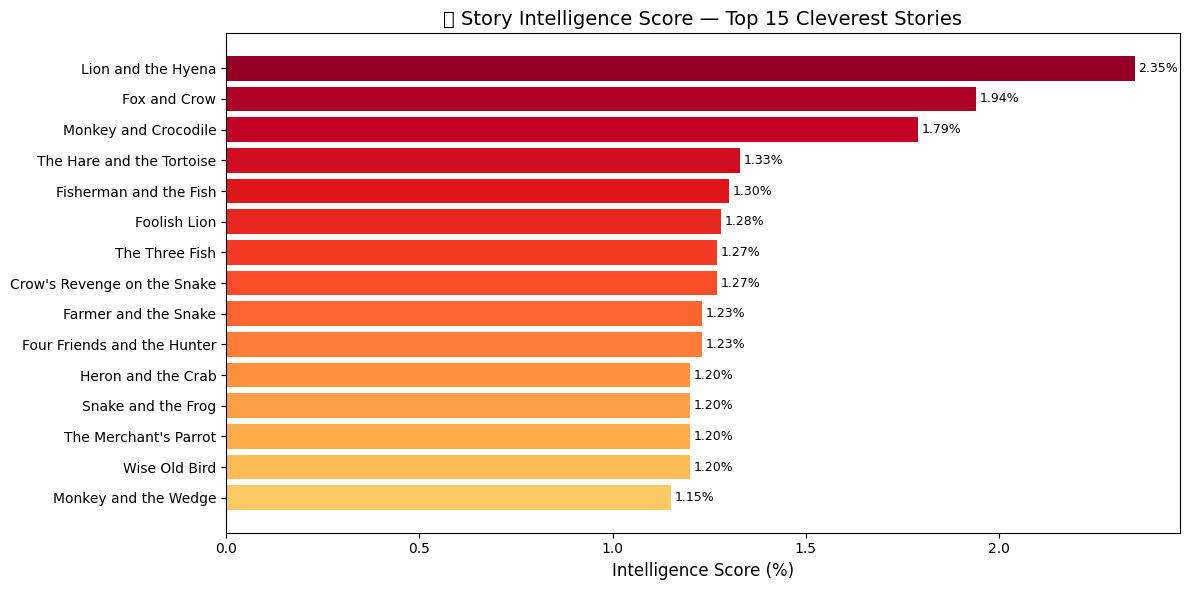

In [ ]:
# Get top 15 stories by intelligence score
top_intel = df[['title', 'intel_score', 'theme']].sort_values('intel_score', ascending=False).head(15)

plt.figure(figsize=(12, 6))
colors3 = plt.cm.YlOrRd(np.linspace(0.3, 0.95, len(top_intel)))
bars = plt.barh(top_intel['title'], top_intel['intel_score'], color=colors3[::-1])
plt.title('🧠 Story Intelligence Score — Top 15 Cleverest Stories', fontsize=14)
plt.xlabel('Intelligence Score (%)', fontsize=12)
plt.gca().invert_yaxis()   # Highest score at the top

for bar, val in zip(bars, top_intel['intel_score']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('intelligence_score.png', dpi=150, bbox_inches='tight')
plt.show()

## 💬 6.8 — Sentiment Analysis per Story

Using VADER sentiment analysis, we score every story from **-1 (very negative)** to **+1 (very positive)**.

- 🔴 Negative stories usually involve betrayal, fear, or punishment
- 🟢 Positive stories usually involve friendship, cooperation, or triumph

/tmp/ipykernel_7735/976518650.py:14: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7735/976518650.py:15: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


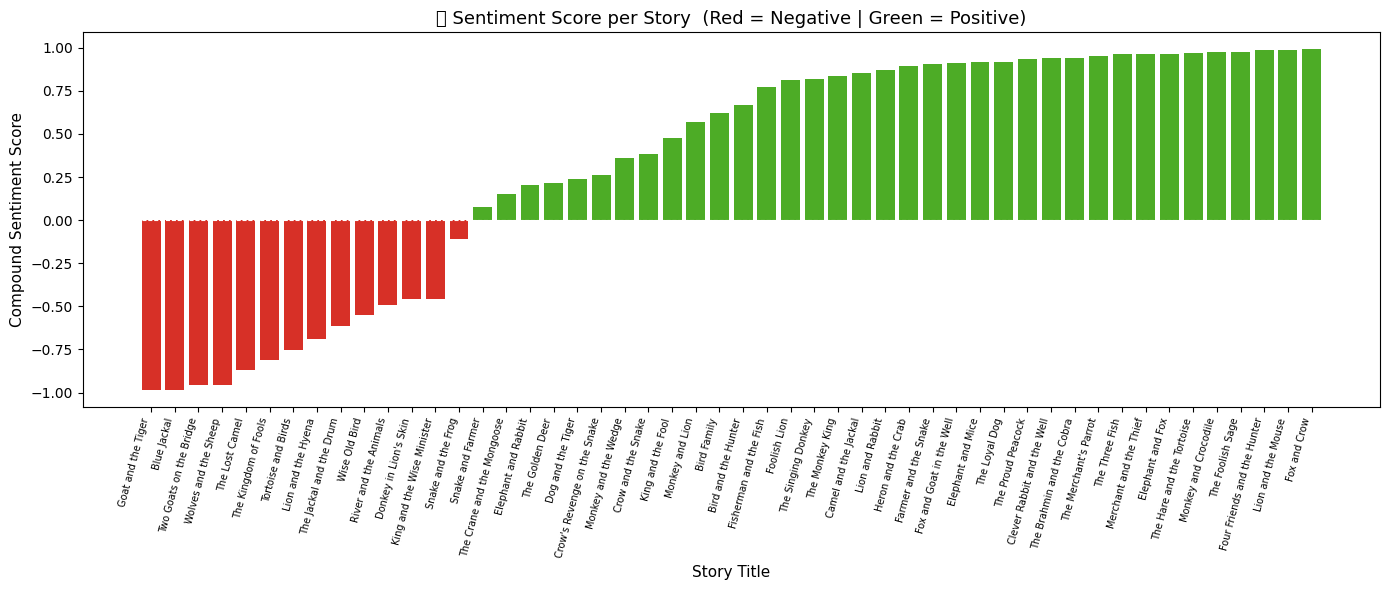

In [ ]:
# Sort stories by sentiment score
df_sent = df[['title', 'sentiment', 'emotion']].sort_values('sentiment')

# Create a colour for each bar: red = negative, green = positive
bar_colors = ['#d73027' if s < 0 else '#4dac26' for s in df_sent['sentiment']]

plt.figure(figsize=(14, 6))
plt.bar(df_sent['title'], df_sent['sentiment'], color=bar_colors, edgecolor='none')
plt.axhline(0, color='white', linewidth=0.8, linestyle='--')
plt.title('💬 Sentiment Score per Story  (Red = Negative | Green = Positive)', fontsize=13)
plt.xlabel('Story Title', fontsize=11)
plt.ylabel('Compound Sentiment Score', fontsize=11)
plt.xticks(rotation=75, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🌐 STEP 7 — Word Co-occurrence Network Graph

A **network graph** shows how words are **connected** to each other across all stories.

- Each **node (circle)** = a meaningful word
- Each **edge (line)** = those two words appear together in 2 or more stories
- **Bigger node** = more connections to other words
- **Node colour** = the moral theme that word belongs to

This is the most visually impressive chart of the project — it shows the **semantic structure** of the entire collection.

In [ ]:
# ── Build co-occurrence edges ───────────────────────────────────────────────────

# Collect all tokens across dataset
all_tokens = [w for token_list in df['tokens'] for w in token_list]
token_freq = Counter(all_tokens)

# Keep only words that appear in 2–40 stories
# Too rare (< 2) = noise | Too common (> 40) = not specific enough
important_words = {w for w, c in token_freq.items() if 2 <= c <= 40}
print(f'✅ Important vocabulary: {len(important_words)} words')

# For each story, find pairs of important words that appear together
edge_counts = defaultdict(int)
for token_list in df['tokens']:
    # Only keep important words, remove duplicates within story
    filtered = list(set([w for w in token_list if w in important_words]))
    # Create all possible pairs from the filtered words
    for w1, w2 in itertools.combinations(sorted(filtered), 2):
        edge_counts[(w1, w2)] += 1

# Keep only word pairs that co-occur in at least 2 stories
edge_counts = {pair: count for pair, count in edge_counts.items() if count >= 2}
print(f'✅ Edges after filtering: {len(edge_counts)}')

✅ Important vocabulary: 979 words
✅ Edges after filtering: 9807


In [ ]:
# ── Build NetworkX graph ────────────────────────────────────────────────────────
G = nx.Graph()

# Add each word pair as an edge with a weight (= co-occurrence count)
for (w1, w2), weight in edge_counts.items():
    G.add_edge(w1, w2, weight=weight)

# Remove nodes that connect to only one other node (too isolated)
G = G.subgraph([n for n in G.nodes() if G.degree(n) > 1]).copy()

# Keep only top 50 most connected nodes — makes the graph readable
top_nodes = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)[:50]
G = G.subgraph(top_nodes).copy()

print(f'✅ Final graph — Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}')

✅ Final graph — Nodes: 50 | Edges: 826


In [ ]:
# ── Colour each node by theme ───────────────────────────────────────────────────
# Map each word to the theme of the first story it appears in
THEME_COLORS = {
    'trust':          '#e74c3c', 'intelligence':   '#3498db',
    'greed':          '#f39c12', 'overconfidence': '#9b59b6',
    'identity':       '#1abc9c', 'cooperation':    '#2ecc71',
    'ego':            '#e67e22', 'gratitude':      '#16a085',
    'wisdom':         '#8e44ad', 'revenge':        '#c0392b',
    'curiosity':      '#d35400', 'sacrifice':      '#27ae60',
    'betrayal':       '#e91e63', 'strategy':       '#00bcd4',
    'survival':       '#ff5722', 'leadership':     '#607d8b',
    'justice':        '#795548', 'unity':          '#4caf50',
    'caution':        '#ffc107', 'bravery':        '#2196f3',
    'teamwork':       '#009688', 'responsibility': '#ff9800',
    'other':          '#95a5a6'
}

word_to_theme = {}
for _, row in df.iterrows():
    theme = str(row['theme']).strip().lower()
    for word in row['tokens']:
        if word not in word_to_theme:
            word_to_theme[word] = theme

node_colors = [THEME_COLORS.get(word_to_theme.get(n, 'other'), '#95a5a6') for n in G.nodes()]

/tmp/ipykernel_7735/2276284161.py:47: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7735/2276284161.py:48: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.savefig('network_graph.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


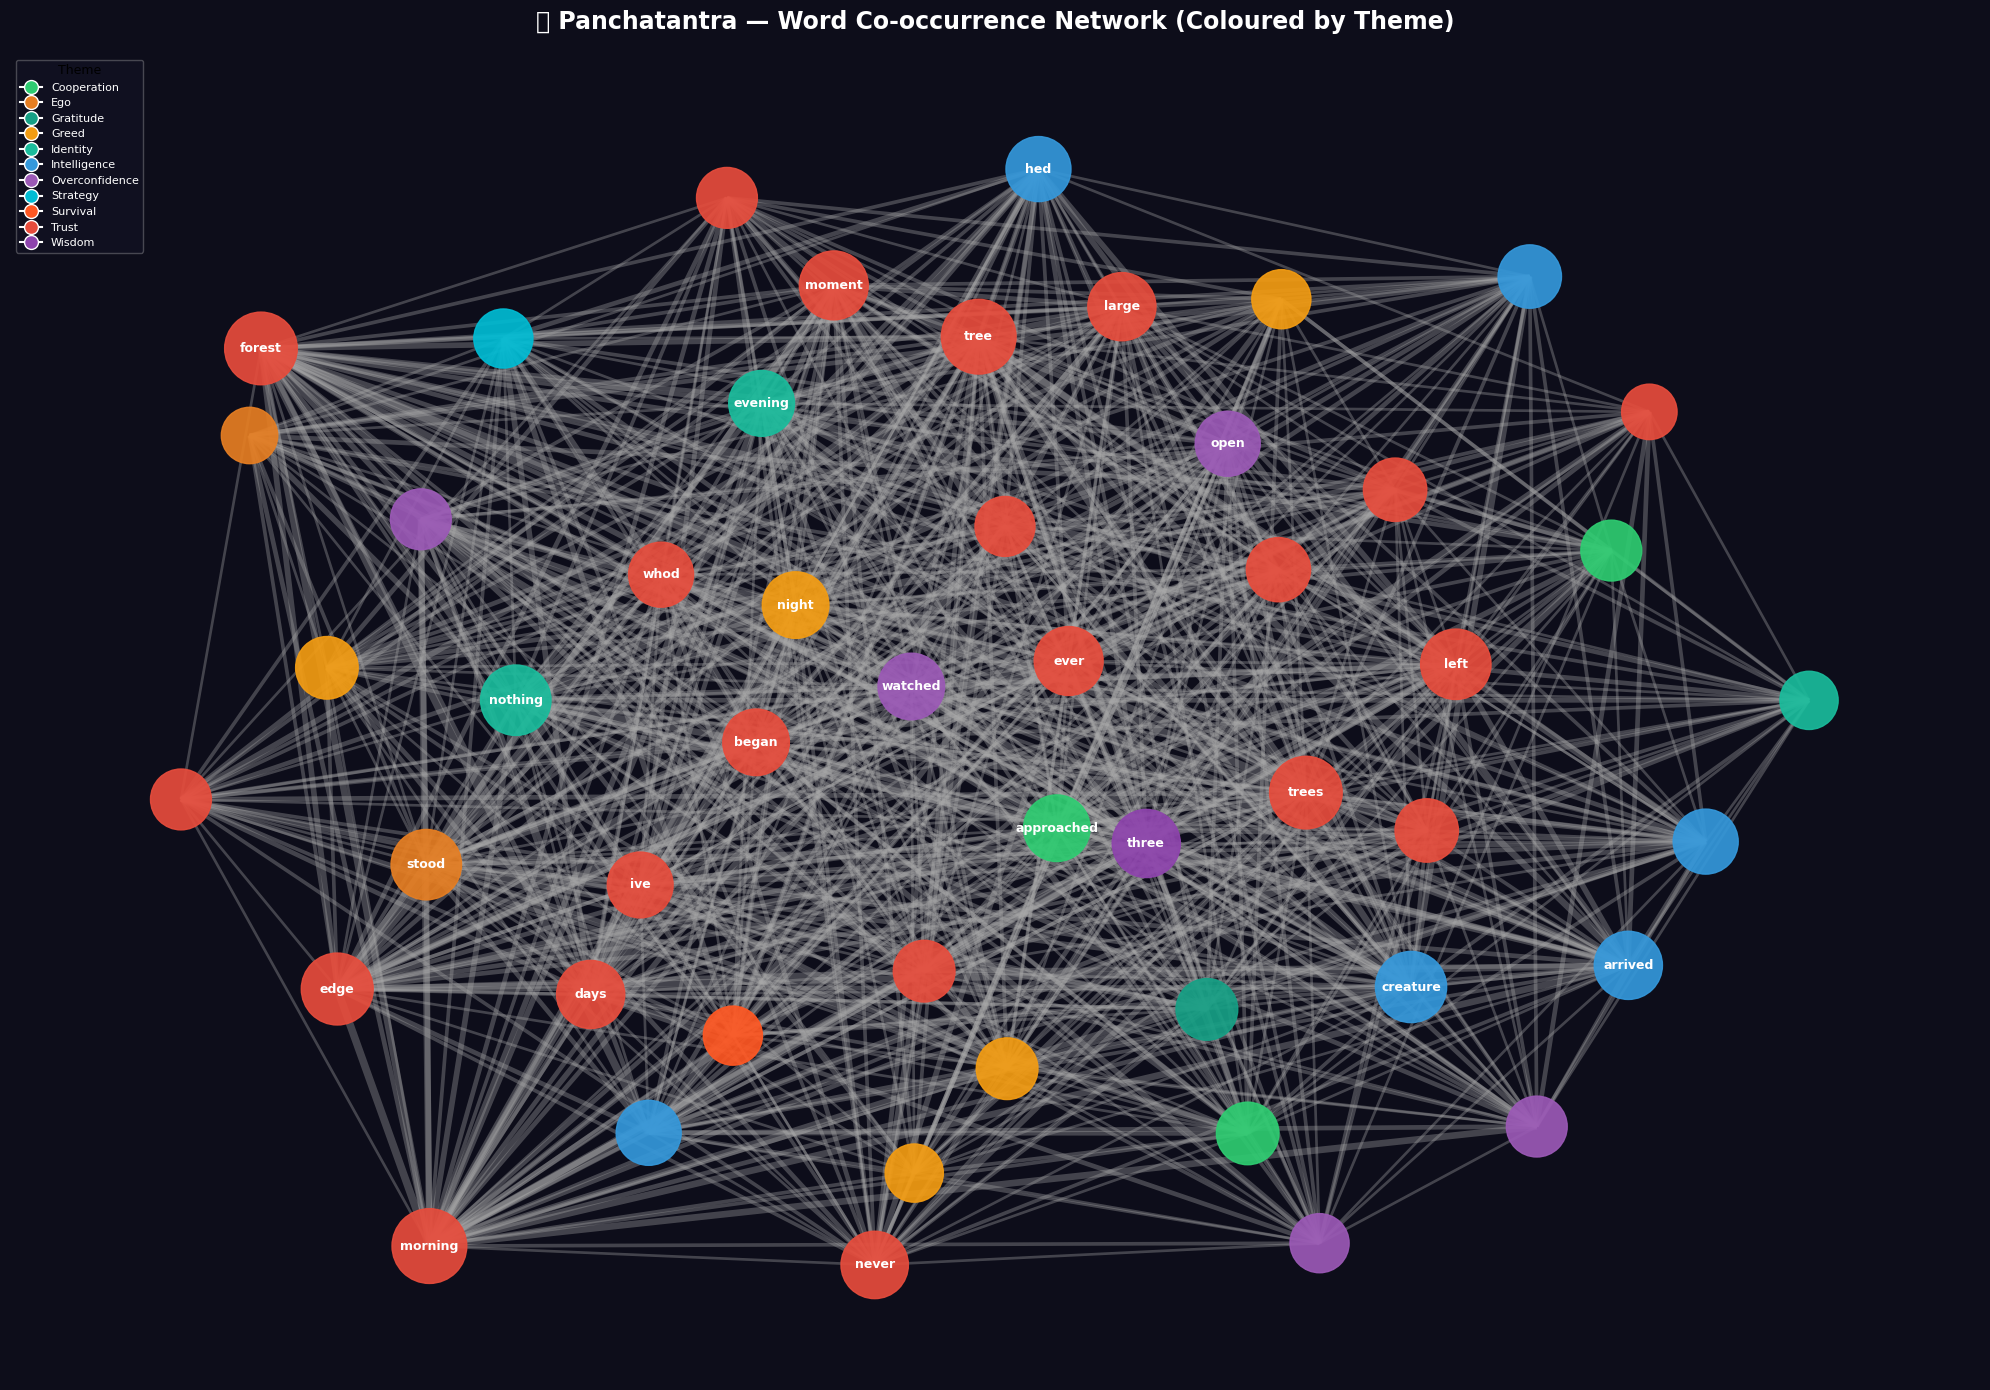

✅ Network graph saved as network_graph.png


In [ ]:
# ── Plot the network graph ──────────────────────────────────────────────────────
degrees      = dict(G.degree())
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_deg      = max(degrees.values()) if degrees else 1
max_ew       = max(edge_weights)     if edge_weights else 1

# Bigger node = more connections
node_sizes  = [400 + (degrees[n] / max_deg) * 2500 for n in G.nodes()]
# Thicker edge = more co-occurrences
edge_widths = [0.5 + (w / max_ew) * 5 for w in edge_weights]

# Kamada-Kawai layout gives a clean, organic arrangement
pos = nx.kamada_kawai_layout(G, weight='weight')

fig_net, ax_net = plt.subplots(figsize=(20, 14))
fig_net.patch.set_facecolor('#0d0d1a')
ax_net.set_facecolor('#0d0d1a')

# Draw edges (lines between words)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.35,
                       edge_color='#aaaaaa', ax=ax_net)

# Draw nodes (word bubbles)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors,
                       alpha=0.92, ax=ax_net)

# Label only the top 25 most connected words (to avoid overcrowding)
top25  = sorted(degrees, key=degrees.get, reverse=True)[:25]
nx.draw_networkx_labels(G, pos, labels={n: n for n in top25},
                        font_size=9, font_color='white', font_weight='bold', ax=ax_net)

# Add a colour legend by theme
seen_themes    = set(word_to_theme.get(n, 'other') for n in G.nodes())
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=THEME_COLORS.get(t, '#95a5a6'),
               markersize=10, label=t.capitalize())
    for t in sorted(seen_themes)
]
ax_net.legend(handles=legend_handles, loc='upper left', framealpha=0.3,
              facecolor='#1a1a2e', labelcolor='white', fontsize=8,
              title='Theme', title_fontsize=9)

ax_net.set_title('🌐 Panchatantra — Word Co-occurrence Network (Coloured by Theme)',
                 fontsize=17, color='white', pad=18, fontweight='bold')
ax_net.axis('off')
plt.tight_layout()
plt.savefig('network_graph.png', dpi=150, bbox_inches='tight',
            facecolor=fig_net.get_facecolor())
plt.show()
print('✅ Network graph saved as network_graph.png')

---
# 🖥️ STEP 8 — Full Interactive Dashboard (Plotly + HTML)

We now combine **all 11 visualisations** into one beautiful, interactive HTML dashboard.

The dashboard includes:
1. ☁️ Word Cloud
2. ☀️ Theme → Emotion Sunburst (interactive — click to explore)
3. 😮 Emotion Distribution
4. 🎯 Moral Themes Donut Chart
5. 🦁 Character Dominance
6. ⚡ Top Action Words
7. 📏 Story Length Distribution
8. 🧠 Intelligence Score (Top 15)
9. 💬 Sentiment per Story
10. 📡 Intelligence by Theme (Radar Chart)
11. 📈 Sentiment Flow per Story (sentence-level)
12. 🔥 Story Similarity Heatmap (TF-IDF)
13. 🌐 Word Co-occurrence Network

After running this cell, the file **`panchatantra_dashboard.html`** will automatically download.
Open it in any browser to view the full interactive dashboard.

In [ ]:
# ── Prepare aggregated data for dashboard charts ────────────────────────────────

theme_counts   = df['theme'].value_counts()
emotion_counts = df['emotion'].value_counts()
char_counts    = df['main_character'].value_counts().head(12)

# TF-IDF similarity matrix — measures how similar each story is to every other
tfidf   = TfidfVectorizer(max_features=200)
tfidf_m = tfidf.fit_transform(df['clean_story'])
sim_mat  = cosine_similarity(tfidf_m)

# Sentiment flow per story (sentence-by-sentence)
def story_sentiment_flow(story_text):
    """Splits a story into sentences and returns sentiment score for each."""
    sentences = re.split(r'[.!?]', str(story_text))
    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]
    return [sia.polarity_scores(s)['compound'] for s in sentences]

print('✅ Dashboard data ready!')

✅ Dashboard data ready!


In [ ]:
# ── Convert matplotlib images (wordcloud + network) to base64 ──────────────────
# Plotly dashboards are HTML files — we embed images as base64 strings
# so the HTML file is fully self-contained (no external image files needed)

# -- Word Cloud --
wc_obj = WordCloud(
    width=900, height=400, background_color='#0d0d1a',
    colormap='plasma', max_words=120, collocations=False, random_state=42
).generate(' '.join(df['clean_story']))

buf_wc = BytesIO()
wc_obj.to_image().save(buf_wc, format='PNG')
wc_img_src = 'data:image/png;base64,' + base64.b64encode(buf_wc.getvalue()).decode()

# -- Network Graph --
fig_net2, ax_net2 = plt.subplots(figsize=(10, 7))
fig_net2.patch.set_facecolor('#0d0d1a')
ax_net2.set_facecolor('#0d0d1a')
edge_w2 = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=[0.5+(w/max(edge_w2))*3 for w in edge_w2],
                       alpha=0.35, edge_color='#aaaaaa', ax=ax_net2)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=degree_vals if 'degree_vals' in dir() else [degrees[n] for n in G.nodes()],
                       cmap=plt.cm.plasma, alpha=0.9, ax=ax_net2)
nx.draw_networkx_labels(G, pos, labels={n: n for n in top25},
                        font_size=7, font_color='white', font_weight='bold', ax=ax_net2)
ax_net2.axis('off')
ax_net2.set_title('Word Co-occurrence Network', color='white', fontsize=11, pad=8)
plt.tight_layout()
buf_net = BytesIO()
fig_net2.savefig(buf_net, format='PNG', dpi=130, bbox_inches='tight',
                 facecolor=fig_net2.get_facecolor())
plt.close(fig_net2)
net_img_src = 'data:image/png;base64,' + base64.b64encode(buf_net.getvalue()).decode()

print('✅ Images converted to base64 for dashboard embedding!')

✅ Images converted to base64 for dashboard embedding!


In [ ]:
# ── Dashboard colour theme ──────────────────────────────────────────────────────
DARK_BG  = '#0d0d1a'
CARD_BG  = '#13132b'
TEXT_COL = '#e0e0f0'
GRID_COL = '#2a2a4a'
ACCENT   = '#a78bfa'
PALETTE  = px.colors.qualitative.Vivid

# Base layout applied to every Plotly chart
layout_base = dict(
    paper_bgcolor = DARK_BG,
    plot_bgcolor  = CARD_BG,
    font          = dict(color=TEXT_COL, family='Arial'),
    margin        = dict(l=40, r=20, t=50, b=40),
)

def apply_dark_axes(fig):
    """Applies dark theme grid colours to x and y axes."""
    fig.update_xaxes(gridcolor=GRID_COL, zerolinecolor=GRID_COL, color=TEXT_COL)
    fig.update_yaxes(gridcolor=GRID_COL, zerolinecolor=GRID_COL, color=TEXT_COL)
    return fig

# ── Figure 1: Emotion Distribution ─────────────────────────────────────────────
fig1 = px.bar(
    x=emotion_counts.index, y=emotion_counts.values,
    color=emotion_counts.index, color_discrete_sequence=PALETTE,
    title='Emotion Distribution Across Stories',
    labels={'x': 'Emotion', 'y': 'Count'}
)
fig1.update_layout(**layout_base, showlegend=False)
apply_dark_axes(fig1)

# ── Figure 2: Moral Themes Donut ────────────────────────────────────────────────
fig2 = px.pie(
    names=theme_counts.index, values=theme_counts.values,
    title='Most Common Moral Themes',
    color_discrete_sequence=PALETTE, hole=0.4
)
fig2.update_layout(**layout_base)
fig2.update_traces(textfont_color='white', pull=[0.05]*len(theme_counts))

# ── Figure 3: Character Dominance ──────────────────────────────────────────────
fig3 = px.bar(
    x=char_series.values,
    y=char_series.index,
    orientation='h',
    color=char_series.values,
    color_continuous_scale='Turbo',  # same as fig6 for consistency
    title='Character Dominance (Top 15 Animals)',
    labels={'x': 'Number of Stories', 'y': 'Character'}
)

# Apply SAME dashboard layout
fig3.update_layout(
    **layout_base,
    coloraxis_showscale=False
)

# Match axis styling
apply_dark_axes(fig3)

# Match orientation style (like earlier)
fig3.update_layout(
    yaxis=dict(autorange='reversed')
)




# ── Figure 4: Top Action Words ──────────────────────────────────────────────────
fig4 = px.bar(
    x=list(top_actions.keys()), y=list(top_actions.values()),
    color=list(top_actions.values()), color_continuous_scale='Viridis',
    title='Top Action Words Across All Stories',
    labels={'x': 'Action', 'y': 'Frequency'}
)
fig4.update_layout(**layout_base, coloraxis_showscale=False)
apply_dark_axes(fig4)

# ── Figure 5: Story Length ──────────────────────────────────────────────────────
fig5 = px.histogram(
    df, x='word_count', nbins=15,
    color_discrete_sequence=[ACCENT],
    title='Story Length Distribution (Word Count)',
    labels={'word_count': 'Words per Story', 'count': 'Frequency'}
)
fig5.update_layout(**layout_base)
apply_dark_axes(fig5)

# ── Figure 6: Intelligence Score ────────────────────────────────────────────────
fig6 = px.bar(
    df.sort_values('intel_score', ascending=False).head(15),
    x='title', y='intel_score',
    color='intel_score', color_continuous_scale='Turbo',
    title='Story Intelligence Score (Top 15)',
    labels={'title': 'Story', 'intel_score': 'Score'}
)
fig6.update_layout(**layout_base, coloraxis_showscale=False, xaxis_tickangle=-35)
apply_dark_axes(fig6)

# ── Figure 7: Sentiment per Story ──────────────────────────────────────────────
fig7 = px.bar(
    df.sort_values('sentiment'),
    x='title', y='sentiment', color='sentiment',
    color_continuous_scale='RdYlGn',
    title='Sentiment Score per Story  (Red = Negative | Green = Positive)',
    labels={'title': 'Story', 'sentiment': 'Sentiment'}
)
fig7.update_layout(**layout_base, coloraxis_showscale=False, xaxis_tickangle=-40)
apply_dark_axes(fig7)

# ── Figure 8: Story Similarity Heatmap ─────────────────────────────────────────
sim_df = pd.DataFrame(sim_mat,
                      index   = df['title'].str[:20],
                      columns = df['title'].str[:20])
fig8 = px.imshow(
    sim_df, color_continuous_scale='Plasma',
    title='Story Similarity Heatmap (TF-IDF Cosine Similarity)',
    aspect='auto'
)
fig8.update_layout(**layout_base, xaxis_tickangle=-45,
                   xaxis=dict(tickfont=dict(size=7)),
                   yaxis=dict(tickfont=dict(size=7)))

# ── Figure 9: Theme × Emotion Sunburst ─────────────────────────────────────────
sun_df = df.groupby(['theme', 'emotion']).size().reset_index(name='count')
fig9 = px.sunburst(
    sun_df, path=['theme', 'emotion'], values='count',
    color='count', color_continuous_scale='Plasma',
    title='Theme → Emotion Sunburst  (Click a theme to explore)'
)
fig9.update_layout(**layout_base)

# ── Figure 10: Sentiment Flow ───────────────────────────────────────────────────
fig10 = go.Figure()
flow_colors = px.colors.qualitative.Pastel
for i, row in df.head(6).iterrows():
    sent_flow = story_sentiment_flow(row['story'])
    fig10.add_trace(go.Scatter(
        x    = list(range(len(sent_flow))),
        y    = sent_flow,
        mode = 'lines+markers',
        name = row['title'][:22],
        line = dict(color=flow_colors[i % len(flow_colors)], width=2),
        marker = dict(size=5)
    ))
fig10.update_layout(
    **layout_base,
    title        = 'Sentiment Flow per Story  (Sentence-level)',
    xaxis_title  = 'Sentence Index',
    yaxis_title  = 'Sentiment Score',
    legend       = dict(bgcolor=CARD_BG, bordercolor=GRID_COL)
)
apply_dark_axes(fig10)

# ── Figure 11: Intelligence by Theme Radar ─────────────────────────────────────
theme_intel = df.groupby('theme')['intel_score'].mean().reset_index()
fig11 = go.Figure(go.Scatterpolar(
    r         = theme_intel['intel_score'],
    theta     = theme_intel['theme'],
    fill      = 'toself',
    line_color  = ACCENT,
    fillcolor   = 'rgba(167,139,250,0.25)'
))
fig11.update_layout(
    **layout_base,
    title = 'Average Intelligence Score by Theme  (Radar)',
    polar = dict(
        bgcolor      = CARD_BG,
        radialaxis   = dict(visible=True, color=TEXT_COL, gridcolor=GRID_COL),
        angularaxis  = dict(color=TEXT_COL, gridcolor=GRID_COL)
    )
)

print('✅ All 11 Plotly figures built!')

✅ All 11 Plotly figures built!


In [ ]:
# ── Helper functions to embed figures into HTML ─────────────────────────────────

def fig_to_html(fig, height='420px'):
    """Converts a Plotly figure to an HTML string for embedding."""
    return pio.to_html(fig, full_html=False,
                       config={'displayModeBar': False},
                       default_height=height)

def image_card(src, title, height='420px'):
    """Wraps a base64 image in a styled dashboard card."""
    return f"""
    <div class="card">
      <div class="card-title">{title}</div>
      <img src="{src}" style="width:100%;height:{height};object-fit:contain;border-radius:8px;">
    </div>"""

# ── Build the full HTML page ────────────────────────────────────────────────────
html_dashboard = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Panchatantra NLP Dashboard</title>
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{
    background: {DARK_BG};
    font-family: Arial, sans-serif;
    color: {TEXT_COL};
    padding: 24px;
  }}
  h1 {{
    text-align: center;
    font-size: 28px;
    color: {ACCENT};
    margin-bottom: 6px;
    letter-spacing: 1px;
  }}
  .subtitle {{
    text-align: center;
    color: #888;
    font-size: 13px;
    margin-bottom: 28px;
  }}
  .stat-row {{
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 16px;
    margin-bottom: 20px;
  }}
  .stat {{
    background: {CARD_BG};
    border-radius: 10px;
    padding: 18px;
    text-align: center;
    border: 1px solid #2a2a4a;
  }}
  .stat-num   {{ font-size: 30px; font-weight: bold; color: {ACCENT}; }}
  .stat-label {{ font-size: 12px; color: #888; margin-top: 5px; }}
  .grid {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 18px;
    margin-bottom: 18px;
  }}
  .single {{ margin-bottom: 18px; }}
  .card {{
    background: {CARD_BG};
    border-radius: 12px;
    padding: 16px;
    border: 1px solid #2a2a4a;
    box-shadow: 0 4px 20px rgba(0,0,0,0.4);
  }}
  .card-title {{
    font-size: 13px;
    color: {ACCENT};
    font-weight: bold;
    margin-bottom: 10px;
    letter-spacing: 0.5px;
  }}
</style>
</head>
<body>

<h1>📖 Panchatantra Stories — NLP Analysis Dashboard</h1>
<p class="subtitle">50 Ancient Indian Fables &nbsp;·&nbsp; 11 Visualisations &nbsp;·&nbsp; Full Interactive Exploration</p>

<!-- SUMMARY STAT CARDS -->
<div class="stat-row">
  <div class="stat">
    <div class="stat-num">{len(df)}</div>
    <div class="stat-label">Total Stories</div>
  </div>
  <div class="stat">
    <div class="stat-num">{df['theme'].nunique()}</div>
    <div class="stat-label">Unique Themes</div>
  </div>
  <div class="stat">
    <div class="stat-num">{df['emotion'].nunique()}</div>
    <div class="stat-label">Emotion Types</div>
  </div>
  <div class="stat">
    <div class="stat-num">{int(df['word_count'].mean())}</div>
    <div class="stat-label">Avg Words / Story</div>
  </div>
</div>

<!-- ROW 1: Word Cloud + Sunburst -->
<div class="grid">
  {image_card(wc_img_src, '☁️ Word Cloud — Most Frequent Words', '340px')}
  <div class="card">
    <div class="card-title">☀️ Theme → Emotion Sunburst (Click a theme to explore)</div>
    {fig_to_html(fig9, '340px')}
  </div>
</div>

<!-- ROW 2: Emotion + Themes -->
<div class="grid">
  <div class="card">
    <div class="card-title">😮 Emotion Distribution</div>
    {fig_to_html(fig1, '360px')}
  </div>
  <div class="card">
    <div class="card-title">🎯 Most Common Moral Themes</div>
    {fig_to_html(fig2, '360px')}
  </div>
</div>

<!-- ROW 3: Character + Action -->
<div class="grid">
  <div class="card">
    <div class="card-title">🦁 Character Dominance</div>
    {fig_to_html(fig3, '380px')}
  </div>
  <div class="card">
    <div class="card-title">⚡ Top Action Words</div>
    {fig_to_html(fig4, '380px')}
  </div>
</div>

<!-- ROW 4: Length + Intelligence -->
<div class="grid">
  <div class="card">
    <div class="card-title">📏 Story Length Distribution</div>
    {fig_to_html(fig5, '340px')}
  </div>
  <div class="card">
    <div class="card-title">🧠 Story Intelligence Score (Top 15)</div>
    {fig_to_html(fig6, '340px')}
  </div>
</div>

<!-- ROW 5: Sentiment + Radar -->
<div class="grid">
  <div class="card">
    <div class="card-title">💬 Sentiment Score per Story</div>
    {fig_to_html(fig7, '380px')}
  </div>
  <div class="card">
    <div class="card-title">📡 Intelligence Score by Theme (Radar)</div>
    {fig_to_html(fig11, '380px')}
  </div>
</div>

<!-- ROW 6: Sentiment Flow (full width) -->
<div class="single">
  <div class="card">
    <div class="card-title">📈 Sentiment Flow per Story (Sentence-level — First 6 Stories)</div>
    {fig_to_html(fig10, '380px')}
  </div>
</div>

<!-- ROW 7: Similarity Heatmap (full width) -->
<div class="single">
  <div class="card">
    <div class="card-title">🔥 Story Similarity Heatmap (TF-IDF Cosine Similarity)</div>
    {fig_to_html(fig8, '580px')}
  </div>
</div>

<!-- ROW 8: Network Graph (full width) -->
<div class="single">
  {image_card(net_img_src, '🌐 Word Co-occurrence Network Graph (Coloured by Theme)', '580px')}
</div>

</body>
</html>
"""

# Save the dashboard to a file
with open('panchatantra_dashboard.html', 'w', encoding='utf-8') as f:
    f.write(html_dashboard)

# Auto-download it
files.download('panchatantra_dashboard.html')

print('✅ Dashboard saved and downloaded as: panchatantra_dashboard.html')
print('📌 Open the file in any browser (Chrome, Firefox, Edge) to view it!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Dashboard saved and downloaded as: panchatantra_dashboard.html
📌 Open the file in any browser (Chrome, Firefox, Edge) to view it!


---
# ✅ STEP 9 — Summary & Insights

Run this cell to print a clean summary of everything we found.

In [ ]:
print('=' * 60)
print('   📖 PANCHATANTRA NLP ANALYSIS — SUMMARY')
print('=' * 60)
print()
print(f'  Total stories analysed     : {len(df)}')
print(f'  Unique moral themes        : {df["theme"].nunique()}')
print(f'  Unique emotion types       : {df["emotion"].nunique()}')
print(f'  Average story length       : {df["word_count"].mean():.1f} words')
print(f'  Vocabulary (unique words)  : {len(set(all_tokens))}')
print()
print('  📌 Most common theme  :', theme_counts.idxmax())
print('  📌 Most common emotion:', emotion_counts.idxmax())
print('  📌 Most common animal :', df["main_character"].value_counts().idxmax())
print()
print('  🧠 Most intelligent story :')
print('    ', df.loc[df['intel_score'].idxmax(), 'title'],
      f'(score: {df["intel_score"].max():.2f}%)')
print()
print('  💚 Most positive story :')
print('    ', df.loc[df['sentiment'].idxmax(), 'title'],
      f'(score: {df["sentiment"].max():.3f})')
print()
print('  ❤️  Most negative story :')
print('    ', df.loc[df['sentiment'].idxmin(), 'title'],
      f'(score: {df["sentiment"].min():.3f})')
print()
print('=' * 60)
print('  📁 Files saved:')
print('     wordcloud.png')
print('     emotion_distribution.png')
print('     theme_distribution.png')
print('     character_dominance.png')
print('     action_words.png')
print('     bigrams.png')
print('     story_length.png')
print('     intelligence_score.png')
print('     sentiment_analysis.png')
print('     network_graph.png')
print('     panchatantra_dashboard.html  ← Open in browser!')
print('=' * 60)

   📖 PANCHATANTRA NLP ANALYSIS — SUMMARY

  Total stories analysed     : 50
  Unique moral themes        : 23
  Unique emotion types       : 13
  Average story length       : 201.2 words
  Vocabulary (unique words)  : 2363

  📌 Most common theme  : trust
  📌 Most common emotion: fear
  📌 Most common animal : other

  🧠 Most intelligent story :
     Lion and the Hyena (score: 2.35%)

  💚 Most positive story :
     Fox and Crow (score: 0.991)

  ❤️  Most negative story :
     Goat and the Tiger (score: -0.986)

  📁 Files saved:
     wordcloud.png
     emotion_distribution.png
     theme_distribution.png
     character_dominance.png
     action_words.png
     bigrams.png
     story_length.png
     intelligence_score.png
     sentiment_analysis.png
     network_graph.png
     panchatantra_dashboard.html  ← Open in browser!
